<a href="https://colab.research.google.com/github/stylekkm051049-bit/Gatekamol-Laosen/blob/main/final_Group_11_%E0%B9%82%E0%B8%A3%E0%B8%87%E0%B9%80%E0%B8%A3%E0%B8%B5%E0%B8%A2%E0%B8%99%E0%B8%81%E0%B8%A7%E0%B8%94%E0%B8%A7%E0%B8%B4%E0%B8%8A%E0%B8%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ระบบลงทะเบียนคอร์สเรียนโรงเรียนกวดวิชา
### Coding Challenge — หัวข้อที่ 11

**องค์กร:** โรงเรียนกวดวิชา  
**ระบบ:** ระบบลงทะเบียนคอร์สเรียน

ระบบจำลองนี้ออกแบบตามรายละเอียดของกลุ่ม โดยมีนักเรียน (Student) เป็นผู้เริ่มต้นกระบวนการ นักเรียนเลือกคอร์ส (Course) จากนั้นระบบตรวจสอบจำนวนที่นั่ง หากยังมีที่ว่างจะสร้างรายการลงทะเบียน (Enrollment) คำนวณค่าเรียนรวม และบันทึกการชำระเงิน (Payment)

ข้อมูลหลักของระบบแบ่งเป็น 4 ส่วน ได้แก่ Student, Course, Enrollment และ Payment โดย Enrollment ทำหน้าที่เชื่อมข้อมูลระหว่าง Student และ Course


##ส่วนที่ 1 - ขั้นตอนการทำงานของระบบ
นักเรียน 1 คนสามารถเลือกได้ 1 คอร์สต่อการลงทะเบียน 1 ครั้ง โดยระบบมีขั้นตอนการทำงานดังนี้
**นักเรียนเลือกคอร์ส → ตรวจสอบที่นั่ง → ลงทะเบียน → คำนวณค่าเรียน → ชำระเงิน → จัดเก็บข้อมูล → วิเคราะห์ข้อมูล**

### ข้อมูลหลัก
- **Student:** รหัสนักเรียน ชื่อ เพศ อายุ ระดับชั้น โรงเรียน และเบอร์โทรศัพท์
- **Course:** รหัสคอร์ส ชื่อคอร์ส วิชา ครูผู้สอน ราคา จำนวนที่นั่ง และจำนวนผู้สมัคร
- **Enrollment:** รหัสการลงทะเบียน รหัสนักเรียน รหัสคอร์ส วันที่ลงทะเบียน ส่วนลด ค่าเรียนรวม และสถานะ
- **Payment:** รหัสการชำระเงิน รหัสการลงทะเบียน วันที่ชำระ จำนวนเงิน วิธีชำระ และสถานะ

ในงานนี้จะจำลองข้อมูลนักเรียน 450 คน และจำลองการลงทะเบียน 450 รายการ โดยใช้ for loop และ random เพื่อจำลองการทำงานของระบบทีละรายการ จากนั้นแปลงข้อมูลเป็น DataFrame และบันทึกเป็นไฟล์ CSV และฐานข้อมูล SQLite เพื่อนำไปวิเคราะห์ข้อมูลด้วย pandas และ SQL


## ส่วนที่ 2 — เตรียม class
ระบบประกอบด้วย 4 Class หลัก ได้แก่ `Student`, `Course`, `Enrollment` และ `Payment`

แต่ละ Class มี Attribute สำหรับเก็บข้อมูล และ Method สำหรับการทำงานของระบบจริง

In [21]:
import random
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

random.seed(11)
print("เตรียม Library เรียบร้อยแล้ว")

เตรียม Library เรียบร้อยแล้ว


In [22]:
class Student:
    def __init__(self, student_id, name, gender, age, grade, school, phone):
        self.student_id = student_id
        self.name = name
        self.gender = gender
        self.age = age
        self.grade = grade
        self.school = school
        self.phone = phone

    def get_grade(self):
        return self.grade

class Course:
    def __init__(self, course_id, course_name, subject, teacher, price, capacity):
        self.course_id = course_id
        self.course_name = course_name
        self.subject = subject
        self.teacher = teacher
        self.price = price
        self.capacity = capacity
        self.enrolled_count = 0

    def has_seat(self):
        return self.enrolled_count < self.capacity

    def add_student(self):
        if self.has_seat():
            self.enrolled_count += 1
            return True
        return False

    def available_seats(self):
        return self.capacity - self.enrolled_count


class Enrollment:
    def __init__(
        self,
        enrollment_id,
        student,
        course,
        enroll_date,
        discount_rate=0
    ):
        self.enrollment_id = enrollment_id
        self.student = student
        self.course = course
        self.enroll_date = enroll_date
        self.discount_rate = discount_rate
        self.total_tuition = 0
        self.status = "รอตรวจสอบ"

    def calculate_total(self):
        discount = self.course.price * self.discount_rate
        self.total_tuition = round(
            self.course.price - discount,
            2
        )
        return self.total_tuition

    def confirm(self):
        if self.course.add_student():
            self.status = "ลงทะเบียนสำเร็จ"
            self.calculate_total()
            return True

        self.status = "คอร์สเต็ม"
        return False


class Payment:
    def __init__(
        self,
        payment_id,
        enrollment,
        payment_date,
        method
    ):
        self.payment_id = payment_id
        self.enrollment = enrollment
        self.payment_date = payment_date
        self.amount = enrollment.total_tuition
        self.method = method
        self.status = "ชำระเงินแล้ว"

    def record_payment(self):
        return self.status


print("สร้าง Class ทั้ง 4 Class สำเร็จ")

สร้าง Class ทั้ง 4 Class สำเร็จ


## ส่วนที่ 3 —  เขียนฟังก์ชันช่วยงาน (Helper Functions)

In [23]:

# เตรียมข้อมูลสำหรับสร้างนักเรียน

FIRST_NAMES = {
    "ชาย": [
        "กิตติ", "ธนภัทร", "ณัฐพงศ์", "พีรพัฒน์",
        "วรเมธ", "ภูริณัฐ", "ชยพล", "ภาคิน",
        "ณัฐวุฒิ", "ศุภกร", "ธนกร", "พศิน",
        "กวิน", "นราวิชญ์", "ปวริศ", "รชต",
        "ธีรภัทร", "ศุภณัฐ", "ภาณุวัฒน์", "พีรวิชญ์",
        "วชิรวิทย์", "ณรงค์ฤทธิ์", "เอกภพ", "สิรภพ",
        "กิตติพงษ์", "ชยุต", "ธนวัฒน์", "ภัทรพล",
        "ณัฐดนัย", "กรวิชญ์", "พีรพงศ์", "ศุภชัย",
        "ธีรเดช", "ปกรณ์", "ภัทรดนัย", "วรากร",
        "กฤติน", "ณัฐภัทร", "ภูวดล", "ธนาธิป",
        "รวิภาส", "ชนนท์", "ก้องภพ", "พงศกร",
        "สิทธิโชค", "อธิพัฒน์", "ปัณณวิชญ์", "ธีรภัทร"
    ],

    "หญิง": [
        "พิมพ์ชนก", "ณิชาภา", "กัญญาวีร์", "ศิริพร",
        "ชลธิชา", "ปภาวดี", "ธัญชนก", "วรัญญา",
        "ณัฐธิดา", "สุภัสสรา", "พิชญาภา", "กมลชนก",
        "ชนัญชิดา", "พัชราภา", "ศศิธร", "ปิยธิดา",
        "ณิชกานต์", "กุลธิดา", "ธนพร", "สิริกัญญา",
        "พิมพ์ลภัส", "อริสา", "ชญาดา", "วริศรา",
        "กัญญาณัฐ", "ณัฐณิชา", "สุพิชญา", "ภัทรวดี",
        "ธัญญารัตน์", "ปุณณภา", "กานต์พิชชา", "นภัสสร",
        "ศุภัคสร", "พิชญ์สินี", "รินรดา", "เขมิกา",
        "อัญชิสา", "ชุติกาญจน์", "พัณณิตา", "ญาดา",
        "ณิชาภัทร", "ปวีณา", "วรรณวิสา", "สุชาดา",
        "พัชรินทร์", "กุลจิรา", "ธิดารัตน์", "อริสรา"
    ]
}

LAST_NAMES = [
    "ใจดี", "ศรีสุข", "สายทอง", "วงศ์ดี", "แก้วมณี",
    "บุญมี", "แสงทอง", "พัฒนกุล", "สุวรรณ", "ธรรมรักษ์",
    "ศรีสวัสดิ์", "เจริญสุข", "วิไลวรรณ", "ทองดี", "บุญส่ง",
    "ศรีวงศ์", "สมบูรณ์", "รัตนวงศ์", "พงษ์ไพบูลย์", "ชัยมงคล",
    "วัฒนกุล", "กิตติชัย", "ศรีเจริญ", "บุญญฤทธิ์", "ไพศาล",
    "วงศ์สุวรรณ", "ธรรมวงศ์", "มงคลชัย", "พรหมรักษา", "จันทร์ดี",
    "ทองคำ", "ศรีบุญเรือง", "บุญเรือง", "วรรณศรี", "สุขเกษม",
    "รัตนชัย", "พูนทรัพย์", "เกียรติศักดิ์", "ชูศรี", "อินทร์แก้ว",
    "แสงจันทร์", "ทองสุข", "บุญธรรม", "ศรีทอง", "แก้วคำ",
    "วงศ์ษา", "สวัสดิ์ชัย", "เจริญวงศ์", "สุริยะ", "ไชยวงศ์",
    "พรมมา", "คำภา", "ศรีสมบัติ", "บุญเลิศ", "ทองใบ",
    "ศรีวิชัย", "สุขสันต์", "รัตนกุล", "วัฒนชัย", "ชนะชัย",
    "พงษ์ศรี", "จันทร์แก้ว", "บุญชู", "ศรีนวล", "แก้วใส",
    "ธรรมวงศ์", "สุวรรณดี", "เจริญทรัพย์", "มณีรัตน์", "ศรีอุดม"
]
SCHOOLS = [
    "โรงเรียนสาธิตมหาวิทยาลัยขอนแก่น ฝ่ายมัธยมศึกษา (ศึกษาศาสตร์)",
    "โรงเรียนสาธิตมหาวิทยาลัยขอนแก่น ฝ่ายมัธยมศึกษา (มอดินแดง)",
    "โรงเรียนขอนแก่นวิทยายน",
    "โรงเรียนกัลยาณวัตร",
    "โรงเรียนแก่นนครวิทยาลัย",
    "โรงเรียนขามแก่นนคร",
    "โรงเรียนนครขอนแก่น",
    "โรงเรียนขอนแก่นวิทยาลัย",
    "โรงเรียนเตรียมอุดมศึกษาพัฒนาการ ขอนแก่น",
    "โรงเรียนขอนแก่นพัฒนศึกษา"
]

GRADE = ["ม.4", "ม.5", "ม.6"]

PAYMENT_METHODS = [
    "โอนธนาคาร",
    "พร้อมเพย์",
    "บัตรเครดิต",
    "เงินสด"
]


In [24]:
#เตรียมข้อมูลคอร์ส
COURSE_MASTER = [

    # ---------------- ม.ปลาย เนื้อหาพื้นฐาน ----------------

    {
        "course_id": "C001",
        "course_name": "คณิตศาสตร์ ม.ปลาย",
        "subject": "คณิตศาสตร์",
        "teacher": "ครูพิมพ์",
        "price": 2800,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C002",
        "course_name": "ฟิสิกส์ ม.ปลาย",
        "subject": "ฟิสิกส์",
        "teacher": "ครูเอก",
        "price": 2800,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C003",
        "course_name": "เคมี ม.ปลาย",
        "subject": "เคมี",
        "teacher": "ครูศิริ",
        "price": 2700,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C004",
        "course_name": "ชีววิทยา ม.ปลาย",
        "subject": "ชีววิทยา",
        "teacher": "ครูแพรว",
        "price": 2700,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C005",
        "course_name": "ภาษาอังกฤษ ม.ปลาย",
        "subject": "ภาษาอังกฤษ",
        "teacher": "ครูณัฐ",
        "price": 2500,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    # ---------------- ติวสอบ A-Level ----------------

    {
        "course_id": "C006",
        "course_name": "คณิตศาสตร์ A-Level",
        "subject": "คณิตศาสตร์",
        "teacher": "ครูพิมพ์",
        "price": 3500,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C007",
        "course_name": "ฟิสิกส์ A-Level",
        "subject": "ฟิสิกส์",
        "teacher": "ครูเอก",
        "price": 3500,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C008",
        "course_name": "เคมี A-Level",
        "subject": "เคมี",
        "teacher": "ครูศิริ",
        "price": 3400,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C009",
        "course_name": "ชีววิทยา A-Level",
        "subject": "ชีววิทยา",
        "teacher": "ครูแพรว",
        "price": 3300,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },

    {
        "course_id": "C010",
        "course_name": "ภาษาอังกฤษ A-Level",
        "subject": "ภาษาอังกฤษ",
        "teacher": "ครูณัฐ",
        "price": 3200,
        "max_seat": 40,
        "target_level": "ม.ปลาย"
    },]

In [25]:
#สร้าง Course Object จาก COURSE_MASTER
courses = {}

for data in COURSE_MASTER:
  course = Course(data["course_id"], data["course_name"], data["subject"], data["teacher"], data["price"], data["max_seat"],)
  courses[course.course_id] = course

print("สร้างคอร์สสำเร็จ:", len(courses), "คอร์ส")


สร้างคอร์สสำเร็จ: 10 คอร์ส


In [26]:
df = pd.DataFrame([
    {
        "course_id": c.course_id,
        "course_name": c.course_name,
        "subject": c.subject,
        "teacher": c.teacher,
        "price": c.price,
        "capacity": c.capacity,
        "enrolled_count": c.enrolled_count,
        "available_seats": c.available_seats()
    }
    for c in courses.values() ])

df.index = df.index + 1

display(df)

,course_id,course_name,subject,teacher,price,capacity,enrolled_count,available_seats
1,C001,คณิตศาสตร์ ม.ปลาย,คณิตศาสตร์,ครูพิมพ์,2800,40,0,40
2,C002,ฟิสิกส์ ม.ปลาย,ฟิสิกส์,ครูเอก,2800,40,0,40
3,C003,เคมี ม.ปลาย,เคมี,ครูศิริ,2700,40,0,40
4,C004,ชีววิทยา ม.ปลาย,ชีววิทยา,ครูแพรว,2700,40,0,40
5,C005,ภาษาอังกฤษ ม.ปลาย,ภาษาอังกฤษ,ครูณัฐ,2500,40,0,40
6,C006,คณิตศาสตร์ A-Level,คณิตศาสตร์,ครูพิมพ์,3500,40,0,40
7,C007,ฟิสิกส์ A-Level,ฟิสิกส์,ครูเอก,3500,40,0,40
8,C008,เคมี A-Level,เคมี,ครูศิริ,3400,40,0,40
9,C009,ชีววิทยา A-Level,ชีววิทยา,ครูแพรว,3300,40,0,40
10,C010,ภาษาอังกฤษ A-Level,ภาษาอังกฤษ,ครูณัฐ,3200,40,0,40


In [27]:
PHONE_PREFIXES = [
    "081", "082", "083", "084", "085",
    "086", "087", "088", "089",
    "091", "092", "093", "094", "095",
    "096", "097", "098", "099"]


def generate_phone():
    """สุ่มเบอร์โทรศัพท์"""
    prefix = random.choice(PHONE_PREFIXES)
    number = random.randint(1000000, 9999999)
    return f"{prefix}-{number}"


def generate_student_name(gender):
    """สุ่มชื่อและนามสกุลตามเพศ"""
    return f"{random.choice(FIRST_NAMES[gender])} {random.choice(LAST_NAMES)}"


def random_date(start="2026-06-01", end="2026-08-20"):
    """สุ่มวันที่ลงทะเบียน"""
    dates = pd.date_range(start, end)
    return random.choice(list(dates)).strftime("%Y-%m-%d")


def format_currency(amount, symbol="บาท"):
    """จัดรูปแบบจำนวนเงิน"""
    return f"{amount:,.2f} {symbol}"

def simulate_registration(
    enrollment_id,
    student,
    course,
    discount_rate=0 ):

    enrollment = Enrollment(
        enrollment_id,
        student,
        course,
        random_date(),
        discount_rate )

    enrollment.confirm()
    return enrollment


# ทดสอบ Helper Functions

print("สร้าง Helper Functions สำเร็จ")
print("\nทดสอบ Function")
print("ชื่อ:", generate_student_name("หญิง"))
print("เบอร์โทร:", generate_phone())
print("วันที่:", random_date())
print("ราคา:", format_currency(course.price))

สร้าง Helper Functions สำเร็จ

ทดสอบ Function
ชื่อ: ธัญญารัตน์ ชนะชัย
เบอร์โทร: 096-9520162
วันที่: 2026-08-15
ราคา: 3,200.00 บาท


### ส่วนที่ 4 — จำลองข้อมูลทีละรายการด้วย Loop

In [28]:
# เตรียมพื้นที่เก็บข้อมูล

students = {}
enrollments = []
payments = []

payment_id = 1

print("เตรียมพื้นที่สำหรับสร้างข้อมูลเรียบร้อยแล้ว")

เตรียมพื้นที่สำหรับสร้างข้อมูลเรียบร้อยแล้ว


In [29]:
# สร้างนักเรียน 450 คน
# จำลองข้อมูลทีละรายการด้วย Loop
random.seed(11)

students = {}

for i in range(1, 451):

    # สุ่มเพศ
    gender = random.choice(["ชาย", "หญิง"])

    # สุ่มระดับชั้นก่อน
    grade = random.choice(GRADE)

    # กำหนดอายุให้สัมพันธ์กับระดับชั้น
    if grade == "ม.4":
        age = random.randint(15, 16)

    elif grade == "ม.5":
        age = random.randint(16, 17)

    else:  # ม.6
        age = random.randint(17, 18)

    # สร้างรหัสนักเรียน
    student_id = f"STU{i:04d}"

    # สร้างนักเรียน
    student = Student(
        student_id,
        generate_student_name(gender),
        gender,
        age,
        grade,
        random.choice(SCHOOLS),
        generate_phone()
    )

    # เก็บข้อมูล
    students[student_id] = student

print(
    f"จำลองนักเรียนเสร็จแล้วทั้งหมด {len(students)} คน"
)

จำลองนักเรียนเสร็จแล้วทั้งหมด 450 คน


In [30]:
for course in courses.values():
    course.enrolled_count = 0

print("รีเซ็ตจำนวนที่นั่งของทุกคอร์สเรียบร้อยแล้ว")

รีเซ็ตจำนวนที่นั่งของทุกคอร์สเรียบร้อยแล้ว


In [31]:
# จำลองการลงทะเบียนทีละรายการ
# นักเรียน 1 คน → เลือก 1 คอร์สต่อการลงทะเบียน
enrollments = []

for enrollment_id, student in enumerate( students.values(), start=1):
    course = random.choice(list(courses.values()))
    discount_rate = random.choice([0, 0.05, 0.10])
    enrollment = simulate_registration(
        enrollment_id,
        student,
        course,
        discount_rate )
    enrollments.append(enrollment)

print("สร้างรายการลงทะเบียน:", len(enrollments), "รายการ" )

สร้างรายการลงทะเบียน: 450 รายการ


In [32]:
# สรุปจำนวนที่นั่งของแต่ละคอร์ส
course_status = []
for course in courses.values():
    available = course.available_seats()
    course_status.append({
        "รหัสคอร์ส": course.course_id,
        "ชื่อคอร์ส": course.course_name,
        "จำนวนที่นั่ง": course.capacity,
        "ลงทะเบียนแล้ว": course.enrolled_count,
        "ที่นั่งคงเหลือ": available,
        "สถานะ": "เต็ม" if available == 0 else "ยังมีที่ว่าง"})
course_status_df = pd.DataFrame(course_status)
display(course_status_df)

,รหัสคอร์ส,ชื่อคอร์ส,จำนวนที่นั่ง,ลงทะเบียนแล้ว,ที่นั่งคงเหลือ,สถานะ
0,C001,คณิตศาสตร์ ม.ปลาย,40,40,0,เต็ม
1,C002,ฟิสิกส์ ม.ปลาย,40,40,0,เต็ม
2,C003,เคมี ม.ปลาย,40,40,0,เต็ม
3,C004,ชีววิทยา ม.ปลาย,40,40,0,เต็ม
4,C005,ภาษาอังกฤษ ม.ปลาย,40,35,5,ยังมีที่ว่าง
5,C006,คณิตศาสตร์ A-Level,40,40,0,เต็ม
6,C007,ฟิสิกส์ A-Level,40,40,0,เต็ม
7,C008,เคมี A-Level,40,40,0,เต็ม
8,C009,ชีววิทยา A-Level,40,38,2,ยังมีที่ว่าง
9,C010,ภาษาอังกฤษ A-Level,40,40,0,เต็ม


In [33]:
# จำลองการชำระเงินทีละรายการ
payments = []
payment_id = 1

for enrollment in enrollments:
    # ตรวจสอบว่าลงทะเบียนสำเร็จหรือไม่
    if enrollment.status == "ลงทะเบียนสำเร็จ":
        payment = Payment(
            payment_id,
            enrollment,
            enrollment.enroll_date,
            random.choice(PAYMENT_METHODS))
        # เก็บข้อมูลการชำระเงิน
        payments.append(payment)
        payment_id += 1

print(f"จำลองการชำระเงินเสร็จแล้วทั้งหมด " f"{len(payments)} รายการ")

จำลองการชำระเงินเสร็จแล้วทั้งหมด 393 รายการ


In [34]:
# สรุปผลการจำลอง
successful = sum( e.status == "ลงทะเบียนสำเร็จ" for e in enrollments )

course_full = sum( e.status == "คอร์สเต็ม" for e in enrollments )

print("\n" + "=" * 60)
print("สรุปผลการจำลองข้อมูล")
print("=" * 60)
print("นักเรียนทั้งหมด       :", len(students))
print("การลงทะเบียนทั้งหมด  :", len(enrollments))
print("ลงทะเบียนสำเร็จ      :", successful)
print("ลงทะเบียนไม่ได้       :", course_full)
print("รายการชำระเงิน       :", len(payments))
print("=" * 60)


สรุปผลการจำลองข้อมูล
นักเรียนทั้งหมด       : 450
การลงทะเบียนทั้งหมด  : 450
ลงทะเบียนสำเร็จ      : 393
ลงทะเบียนไม่ได้       : 57
รายการชำระเงิน       : 393


## ขั้นที่ 5: Demo การลงทะเบียน 1 รายการ

จำลองกระบวนการจริงตามลำดับ: นักเรียนเลือกคอร์ส → ตรวจสอบที่นั่ง → ลงทะเบียน → คำนวณค่าเรียน → ชำระเงิน

In [35]:
demo_student = Student( "DEMO001", "พิมพ์ชนก ศรีสุข", "หญิง", 17, "ม.5", "โรงเรียนขอนแก่นวิทยายน", "08-1234-5678")

demo_course = Course( "D001", "คณิตศาสตร์ A-Level", "คณิตศาสตร์", "ครูพิมพ์", 3500, 40)

print("=" * 60)
print("DEMO : กระบวนการลงทะเบียนเรียน")
print("=" * 60)

# 1. แสดงข้อมูลนักเรียน

print("ข้อมูลนักเรียน")
print("รหัสนักเรียน :", demo_student.student_id)
print("ชื่อ          :", demo_student.name)
print("เพศ          :", demo_student.gender)
print("อายุ          :", demo_student.age)
print("ชั้นเรียน     :", demo_student.grade)
print("โรงเรียน      :", demo_student.school)
print("เบอร์โทร      :", demo_student.phone)
print("-" * 60)

# 2. นักเรียนเลือกคอร์ส

print("นักเรียนเลือกคอร์ส:", demo_course.course_name)
print("วิชา            :", demo_course.subject)
print("ครูผู้สอน        :", demo_course.teacher)
print("ราคาเต็ม         :", format_currency(demo_course.price))

# 3. ตรวจสอบที่นั่งก่อนสมัคร

print( "ที่นั่งก่อนสมัคร  :", demo_course.available_seats() )

# 4. ลงทะเบียน

demo_enrollment = simulate_registration(
    1,
    demo_student,
    demo_course,
    discount_rate=0.10 )

print("สถานะการลงทะเบียน:", demo_enrollment.status)

# 5. ถ้าลงทะเบียนสำเร็จ

if demo_enrollment.status == "ลงทะเบียนสำเร็จ":

    print( "ส่วนลด         :", f"{demo_enrollment.discount_rate * 100:.0f}%")

    print("ค่าเรียนสุทธิ      :", format_currency(demo_enrollment.total_tuition))

    print("ที่นั่งหลังสมัคร    :", demo_course.available_seats())

    # 6. ชำระเงิน

    demo_payment = Payment(
        1,
        demo_enrollment,
        demo_enrollment.enroll_date,
        "พร้อมเพย์" )

    print("การชำระเงิน        :", demo_payment.record_payment())
    print("จำนวนเงิน          :", format_currency(demo_payment.amount))
    print("วิธีชำระ            :", demo_payment.method)

else:

    print("ไม่สามารถลงทะเบียนได้ เนื่องจากคอร์สเต็ม")

print("=" * 60)
print("จบ DEMO")
print("=" * 60)

DEMO : กระบวนการลงทะเบียนเรียน
ข้อมูลนักเรียน
รหัสนักเรียน : DEMO001
ชื่อ          : พิมพ์ชนก ศรีสุข
เพศ          : หญิง
อายุ          : 17
ชั้นเรียน     : ม.5
โรงเรียน      : โรงเรียนขอนแก่นวิทยายน
เบอร์โทร      : 08-1234-5678
------------------------------------------------------------
นักเรียนเลือกคอร์ส: คณิตศาสตร์ A-Level
วิชา            : คณิตศาสตร์
ครูผู้สอน        : ครูพิมพ์
ราคาเต็ม         : 3,500.00 บาท
ที่นั่งก่อนสมัคร  : 40
สถานะการลงทะเบียน: ลงทะเบียนสำเร็จ
ส่วนลด         : 10%
ค่าเรียนสุทธิ      : 3,150.00 บาท
ที่นั่งหลังสมัคร    : 39
การชำระเงิน        : ชำระเงินแล้ว
จำนวนเงิน          : 3,150.00 บาท
วิธีชำระ            : พร้อมเพย์
จบ DEMO


In [36]:
# DEMO — นักเรียน 1 คน ลงทะเบียนหลายคอร์ส
# ในการลงทะเบียน 1 ครั้ง
# ==========================================

demo_student = Student( "DEMO001", "พิมพ์ชนก ศรีสุข", "หญิง", 17, "ม.5", "โรงเรียนขอนแก่นวิทยายน", "08-1234-5678")

# คอร์สที่นักเรียนเลือก
demo_courses = [
    Course(
        "D001",
        "คณิตศาสตร์ A-Level",
        "คณิตศาสตร์",
        "ครูพิมพ์",
        3500,
        40
    ),

    Course(
        "D002",
        "ฟิสิกส์ A-Level",
        "ฟิสิกส์",
        "ครูเอก",
        3500,
        40
    ),

    Course(
        "D003",
        "เคมี A-Level",
        "เคมี",
        "ครูศิริ",
        3400,
        40 )]

print("=" * 60)
print("DEMO : ลงทะเบียนหลายคอร์สในครั้งเดียว")
print("=" * 60)

# ข้อมูลนักเรียน

print("รหัสนักเรียน :", demo_student.student_id)
print("ชื่อ          :", demo_student.name)
print("ชั้นเรียน     :", demo_student.grade)
print("โรงเรียน      :", demo_student.school)
print("เบอร์โทร      :", demo_student.phone)
print("-" * 60)
print("นักเรียนเลือกทั้งหมด:", len(demo_courses), "คอร์ส")
print()

# ลงทะเบียนทีละคอร์ส

demo_enrollments = []
demo_payments = []

for enrollment_id, course in enumerate(
    demo_courses,
    start=1):

    print("คอร์สที่", enrollment_id)
    print("ชื่อคอร์ส       :", course.course_name)
    print("ราคาเต็ม        :", format_currency(course.price))
    print("ที่นั่งก่อนสมัคร :", course.available_seats())

    # สุ่มส่วนลด
    discount_rate = random.choice([
        0,
        0.05,
        0.10 ])

    # ลงทะเบียน
    enrollment = simulate_registration(
        enrollment_id,
        demo_student,
        course,
        discount_rate)

    demo_enrollments.append(enrollment)

    print("สถานะ           :", enrollment.status)

    if enrollment.status == "ลงทะเบียนสำเร็จ":   # ถ้าลงทะเบียนสำเร็จ → ชำระเงินอ

        print( "ส่วนลด          :", f"{discount_rate * 100:.0f}%" )
        print( "ค่าเรียนสุทธิ    :", format_currency(enrollment.total_tuition))
        print( "ที่นั่งหลังสมัคร  :", course.available_seats())

        payment = Payment(
            enrollment_id,
            enrollment,
            enrollment.enroll_date,
            "พร้อมเพย์" )

        demo_payments.append(payment)
        print( "การชำระเงิน      :", payment.record_payment())
        print( "จำนวนเงิน        :", format_currency(payment.amount))
        print( "วิธีชำระ          :", payment.method )

    else:
        print("ไม่สามารถชำระเงินได้ เนื่องจากคอร์สเต็ม")

    print("-" * 60)


# สรุป Demo

successful = sum(e.status == "ลงทะเบียนสำเร็จ" for e in demo_enrollments)

full = sum(e.status == "คอร์สเต็ม" for e in demo_enrollments)

total_tuition = sum(e.total_tuition for e in demo_enrollments if e.status == "ลงทะเบียนสำเร็จ")

print("สรุปผล Demo")
print("นักเรียน :", demo_student.name)
print("คอร์สที่เลือก :", len(demo_courses))
print("ลงทะเบียนสำเร็จ :", successful)
print("คอร์สเต็ม :", full)
print("ค่าเรียนรวม :", format_currency(total_tuition))
print("ชำระเงินสำเร็จ :", len(demo_payments))
print("=" * 60)

DEMO : ลงทะเบียนหลายคอร์สในครั้งเดียว
รหัสนักเรียน : DEMO001
ชื่อ          : พิมพ์ชนก ศรีสุข
ชั้นเรียน     : ม.5
โรงเรียน      : โรงเรียนขอนแก่นวิทยายน
เบอร์โทร      : 08-1234-5678
------------------------------------------------------------
นักเรียนเลือกทั้งหมด: 3 คอร์ส

คอร์สที่ 1
ชื่อคอร์ส       : คณิตศาสตร์ A-Level
ราคาเต็ม        : 3,500.00 บาท
ที่นั่งก่อนสมัคร : 40
สถานะ           : ลงทะเบียนสำเร็จ
ส่วนลด          : 10%
ค่าเรียนสุทธิ    : 3,150.00 บาท
ที่นั่งหลังสมัคร  : 39
การชำระเงิน      : ชำระเงินแล้ว
จำนวนเงิน        : 3,150.00 บาท
วิธีชำระ          : พร้อมเพย์
------------------------------------------------------------
คอร์สที่ 2
ชื่อคอร์ส       : ฟิสิกส์ A-Level
ราคาเต็ม        : 3,500.00 บาท
ที่นั่งก่อนสมัคร : 40
สถานะ           : ลงทะเบียนสำเร็จ
ส่วนลด          : 0%
ค่าเรียนสุทธิ    : 3,500.00 บาท
ที่นั่งหลังสมัคร  : 39
การชำระเงิน      : ชำระเงินแล้ว
จำนวนเงิน        : 3,500.00 บาท
วิธีชำระ          : พร้อมเพย์
----------------------------------------------------------

ขั้นที่ 6 — แปลง Object เป็น DataFrame

In [37]:
import pandas as pd

# สร้าง dictionary สำหรับค้นหาข้อมูลการชำระเงิน
payment_dict = {
    p.enrollment.enrollment_id: p
    for p in payments
}


registration_data = []

for e in enrollments:

    # หาข้อมูลการชำระเงินของรายการนี้
    payment = payment_dict.get(e.enrollment_id)

    registration_data.append({

        # ---------------- Student ----------------
        "รหัสนักเรียน": e.student.student_id,
        "ชื่อ-นามสกุล": e.student.name,
        "เพศ": e.student.gender,
        "อายุ": e.student.age,
        "ระดับชั้น": e.student.grade,
        "โรงเรียน": e.student.school,
        "เบอร์โทรติดต่อ": e.student.phone,

        # ---------------- Course ----------------
        "รหัสคอร์ส": e.course.course_id,
        "ชื่อคอร์ส": e.course.course_name,
        "รายวิชา": e.course.subject,
        "อาจารย์ผู้สอน": e.course.teacher,
        "ราคา(บาท)": e.course.price,
        "จำนวนรับสูงสุด": e.course.capacity,
        "จำนวนผู้ลงทะเบียน": e.course.enrolled_count,
        "ที่นั่งคงเหลือ": e.course.available_seats(),

        # ---------------- Enrollment ----------------
        "รหัสการลงทะเบียน": e.enrollment_id,
        "วันที่ลงทะเบียน": e.enroll_date,
        "ส่วนลด": e.discount_rate,

        # ใช้ total_tuition ตามที่คุณใช้ใน Demo
        "ยอดชำระสุทธิ (บาท)": e.total_tuition,

        "สถานะการลงทะเบียน": e.status,

        # ---------------- Payment ----------------
        "รหัสการชำระเงิน":
            payment.payment_id if payment else None,

        "จำนวนเงินที่ชำระ(บาท)":
            payment.amount if payment else None,

        "ช่องทางการชำระเงิน":
            payment.method if payment else None,

        "วันที่ชำระเงิน":
            payment.payment_date if payment else None,

        "สถานะการชำระเงิน":
            payment.status if payment else None
    })


# สร้าง DataFrame
registration_df = pd.DataFrame(registration_data)


# เริ่มเลขแถวที่ 1
registration_df.index = range(
    1,
    len(registration_df) + 1
)


# แสดงข้อมูล 450 รายการ
display(registration_df.head(450))


# ตรวจสอบจำนวน
print("จำนวนรายการทั้งหมด:", len(registration_df))

,รหัสนักเรียน,ชื่อ-นามสกุล,เพศ,อายุ,ระดับชั้น,โรงเรียน,เบอร์โทรติดต่อ,รหัสคอร์ส,ชื่อคอร์ส,รายวิชา,...,รหัสการลงทะเบียน,วันที่ลงทะเบียน,ส่วนลด,ยอดชำระสุทธิ (บาท),สถานะการลงทะเบียน,รหัสการชำระเงิน,จำนวนเงินที่ชำระ(บาท),ช่องทางการชำระเงิน,วันที่ชำระเงิน,สถานะการชำระเงิน
1,STU0001,ธัญญารัตน์ ธรรมวงศ์,หญิง,18,ม.6,โรงเรียนขอนแก่นพัฒนศึกษา,087-4098086,C008,เคมี A-Level,เคมี,...,1,2026-08-04,0.10,3060.0,ลงทะเบียนสำเร็จ,1.0,3060.0,โอนธนาคาร,2026-08-04,ชำระเงินแล้ว
2,STU0002,ธัญชนก รัตนกุล,หญิง,17,ม.6,โรงเรียนแก่นนครวิทยาลัย,085-2521199,C007,ฟิสิกส์ A-Level,ฟิสิกส์,...,2,2026-07-21,0.05,3325.0,ลงทะเบียนสำเร็จ,2.0,3325.0,โอนธนาคาร,2026-07-21,ชำระเงินแล้ว
3,STU0003,ณัฐดนัย วัฒนกุล,ชาย,18,ม.6,โรงเรียนขอนแก่นพัฒนศึกษา,081-9864766,C008,เคมี A-Level,เคมี,...,3,2026-08-01,0.05,3230.0,ลงทะเบียนสำเร็จ,3.0,3230.0,เงินสด,2026-08-01,ชำระเงินแล้ว
4,STU0004,กวิน ทองคำ,ชาย,15,ม.4,โรงเรียนขอนแก่นพัฒนศึกษา,081-8783528,C006,คณิตศาสตร์ A-Level,คณิตศาสตร์,...,4,2026-06-16,0.00,3500.0,ลงทะเบียนสำเร็จ,4.0,3500.0,บัตรเครดิต,2026-06-16,ชำระเงินแล้ว
5,STU0005,พิชญ์สินี จันทร์ดี,หญิง,16,ม.5,โรงเรียนแก่นนครวิทยาลัย,097-1077070,C001,คณิตศาสตร์ ม.ปลาย,คณิตศาสตร์,...,5,2026-07-22,0.10,2520.0,ลงทะเบียนสำเร็จ,5.0,2520.0,เงินสด,2026-07-22,ชำระเงินแล้ว
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,STU0446,วรเมธ วัฒนกุล,ชาย,17,ม.6,โรงเรียนเตรียมอุดมศึกษาพัฒนาการ ขอนแก่น,093-3149106,C002,ฟิสิกส์ ม.ปลาย,ฟิสิกส์,...,446,2026-06-16,0.05,0.0,คอร์สเต็ม,NaN,NaN,None,None,None
447,STU0447,ภาคิน เจริญวงศ์,ชาย,18,ม.6,โรงเรียนขามแก่นนคร,095-5040030,C001,คณิตศาสตร์ ม.ปลาย,คณิตศาสตร์,...,447,2026-06-07,0.10,0.0,คอร์สเต็ม,NaN,NaN,None,None,None
448,STU0448,ภาณุวัฒน์ สุขสันต์,ชาย,18,ม.6,โรงเรียนแก่นนครวิทยาลัย,095-8858666,C005,ภาษาอังกฤษ ม.ปลาย,ภาษาอังกฤษ,...,448,2026-06-23,0.00,2500.0,ลงทะเบียนสำเร็จ,393.0,2500.0,บัตรเครดิต,2026-06-23,ชำระเงินแล้ว
449,STU0449,พีรพงศ์ วรรณศรี,ชาย,16,ม.4,โรงเรียนขอนแก่นวิทยาลัย,098-3630919,C008,เคมี A-Level,เคมี,...,449,2026-07-30,0.00,0.0,คอร์สเต็ม,NaN,NaN,None,None,None


จำนวนรายการทั้งหมด: 450


In [38]:
registration_df.to_csv("ข้อมูลการลงทะเบียนคอร์สเรียน.csv",index=False,encoding="utf-8-sig")

print("บันทึก CSV สำเร็จ 450 รายการ")

บันทึก CSV สำเร็จ 450 รายการ


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
import os
os.makedirs( "/content/drive/MyDrive/BAA-moire", exist_ok=True )

## ขั้นที่ 7 — สร้างฐานข้อมูล SQLite จากข้อมูลเดียวกัน

In [40]:
import sqlite3

# เชื่อมต่อ SQLite
conn = sqlite3.connect("tutoring_school.db")

# นำ DataFrame เดียวเข้า SQLite
registration_df.to_sql(
    "registration",
    conn,
    if_exists="replace",
    index=False
)

print("สร้าง SQLite Database สำเร็จ")

สร้าง SQLite Database สำเร็จ


In [41]:
# ทดสอบข้อมูล
check = pd.read_sql_query( "SELECT * FROM registration LIMIT 5", conn)
display(check)

,รหัสนักเรียน,ชื่อ-นามสกุล,เพศ,อายุ,ระดับชั้น,โรงเรียน,เบอร์โทรติดต่อ,รหัสคอร์ส,ชื่อคอร์ส,รายวิชา,...,รหัสการลงทะเบียน,วันที่ลงทะเบียน,ส่วนลด,ยอดชำระสุทธิ (บาท),สถานะการลงทะเบียน,รหัสการชำระเงิน,จำนวนเงินที่ชำระ(บาท),ช่องทางการชำระเงิน,วันที่ชำระเงิน,สถานะการชำระเงิน
0,STU0001,ธัญญารัตน์ ธรรมวงศ์,หญิง,18,ม.6,โรงเรียนขอนแก่นพัฒนศึกษา,087-4098086,C008,เคมี A-Level,เคมี,...,1,2026-08-04,0.10,3060.0,ลงทะเบียนสำเร็จ,1.0,3060.0,โอนธนาคาร,2026-08-04,ชำระเงินแล้ว
1,STU0002,ธัญชนก รัตนกุล,หญิง,17,ม.6,โรงเรียนแก่นนครวิทยาลัย,085-2521199,C007,ฟิสิกส์ A-Level,ฟิสิกส์,...,2,2026-07-21,0.05,3325.0,ลงทะเบียนสำเร็จ,2.0,3325.0,โอนธนาคาร,2026-07-21,ชำระเงินแล้ว
2,STU0003,ณัฐดนัย วัฒนกุล,ชาย,18,ม.6,โรงเรียนขอนแก่นพัฒนศึกษา,081-9864766,C008,เคมี A-Level,เคมี,...,3,2026-08-01,0.05,3230.0,ลงทะเบียนสำเร็จ,3.0,3230.0,เงินสด,2026-08-01,ชำระเงินแล้ว
3,STU0004,กวิน ทองคำ,ชาย,15,ม.4,โรงเรียนขอนแก่นพัฒนศึกษา,081-8783528,C006,คณิตศาสตร์ A-Level,คณิตศาสตร์,...,4,2026-06-16,0.00,3500.0,ลงทะเบียนสำเร็จ,4.0,3500.0,บัตรเครดิต,2026-06-16,ชำระเงินแล้ว
4,STU0005,พิชญ์สินี จันทร์ดี,หญิง,16,ม.5,โรงเรียนแก่นนครวิทยาลัย,097-1077070,C001,คณิตศาสตร์ ม.ปลาย,คณิตศาสตร์,...,5,2026-07-22,0.10,2520.0,ลงทะเบียนสำเร็จ,5.0,2520.0,เงินสด,2026-07-22,ชำระเงินแล้ว


In [42]:
# ตรวจสอบว่ามีครบ 450 รายการ
check_count = pd.read_sql_query( "SELECT COUNT(*) AS จำนวนรายการ FROM registration", conn)
display(check_count)

,จำนวนรายการ
0,450


## ขั้นที่ 8 — วิเคราะห์ข้อมูลด้วย pandas และ SQL

วิเคราะห์ด้วย PANDAS

In [43]:

# คอร์สไหนมีผู้สมัครมากที่สุด
q1_pandas = (
    registration_df[
        registration_df["สถานะการลงทะเบียน"] == "ลงทะเบียนสำเร็จ"
    ]
    .groupby(["รหัสคอร์ส", "ชื่อคอร์ส"])
    .size()
    .reset_index(name="จำนวนผู้สมัคร")
    .sort_values("จำนวนผู้สมัคร", ascending=False)
)

display(q1_pandas)

,รหัสคอร์ส,ชื่อคอร์ส,จำนวนผู้สมัคร
0,C001,คณิตศาสตร์ ม.ปลาย,40
1,C002,ฟิสิกส์ ม.ปลาย,40
2,C003,เคมี ม.ปลาย,40
3,C004,ชีววิทยา ม.ปลาย,40
5,C006,คณิตศาสตร์ A-Level,40
6,C007,ฟิสิกส์ A-Level,40
9,C010,ภาษาอังกฤษ A-Level,40
7,C008,เคมี A-Level,40
8,C009,ชีววิทยา A-Level,38
4,C005,ภาษาอังกฤษ ม.ปลาย,35


In [44]:
# คอร์สไหนรายได้มากที่สุด
q2_pandas = (
    registration_df[
        registration_df["สถานะการลงทะเบียน"] == "ลงทะเบียนสำเร็จ"
    ]
    .groupby(["รหัสคอร์ส", "ชื่อคอร์ส"])
    ["ยอดชำระสุทธิ (บาท)"]
    .sum()
    .reset_index(name="รายได้รวม")
    .sort_values("รายได้รวม", ascending=False)
)

display(q2_pandas)

,รหัสคอร์ส,ชื่อคอร์ส,รายได้รวม
5,C006,คณิตศาสตร์ A-Level,132825.0
6,C007,ฟิสิกส์ A-Level,132475.0
7,C008,เคมี A-Level,129370.0
9,C010,ภาษาอังกฤษ A-Level,121120.0
8,C009,ชีววิทยา A-Level,119955.0
1,C002,ฟิสิกส์ ม.ปลาย,107660.0
0,C001,คณิตศาสตร์ ม.ปลาย,104720.0
3,C004,ชีววิทยา ม.ปลาย,102735.0
2,C003,เคมี ม.ปลาย,102330.0
4,C005,ภาษาอังกฤษ ม.ปลาย,83625.0


In [45]:
# โรงเรียนไหนมีนักเรียนลงทะเบียนมากที่สุด?
q4_pandas = (
    registration_df[
        registration_df["สถานะการลงทะเบียน"] == "ลงทะเบียนสำเร็จ"
    ]
    .groupby("โรงเรียน")
    .size()
    .reset_index(name="จำนวนผู้ลงทะเบียน")
    .sort_values("จำนวนผู้ลงทะเบียน", ascending=False)
)

display(q4_pandas)

,โรงเรียน,จำนวนผู้ลงทะเบียน
9,โรงเรียนแก่นนครวิทยาลัย,52
6,โรงเรียนสาธิตมหาวิทยาลัยขอนแก่น ฝ่ายมัธยมศึกษา...,44
3,โรงเรียนขอนแก่นวิทยาลัย,40
0,โรงเรียนกัลยาณวัตร,39
1,โรงเรียนขอนแก่นพัฒนศึกษา,39
7,โรงเรียนสาธิตมหาวิทยาลัยขอนแก่น ฝ่ายมัธยมศึกษา...,38
2,โรงเรียนขอนแก่นวิทยายน,37
8,โรงเรียนเตรียมอุดมศึกษาพัฒนาการ ขอนแก่น,37
5,โรงเรียนนครขอนแก่น,36
4,โรงเรียนขามแก่นนคร,31


In [46]:
# รายได้รวมทั้งหมด
total_revenue = registration_df.loc[
    registration_df["สถานะการลงทะเบียน"] == "ลงทะเบียนสำเร็จ",
    "ยอดชำระสุทธิ (บาท)"
].sum()

print(
    "รายได้รวมทั้งหมด:",
    format_currency(total_revenue)
)

รายได้รวมทั้งหมด: 1,136,815.00 บาท


วิเคราะห์คำถามเดียวกันด้วย SQL

In [47]:
conn = sqlite3.connect("tutoring_school.db")

In [48]:
# คอร์สไหนมีผู้สมัครมากที่สุด?
q1_sql = pd.read_sql_query("""
SELECT
    "รหัสคอร์ส",
    "ชื่อคอร์ส",
    COUNT(*) AS จำนวนผู้สมัคร
FROM registration
WHERE "สถานะการลงทะเบียน" = 'ลงทะเบียนสำเร็จ'
GROUP BY "รหัสคอร์ส", "ชื่อคอร์ส"
ORDER BY จำนวนผู้สมัคร DESC
""", conn)

display(q1_sql)

,รหัสคอร์ส,ชื่อคอร์ส,จำนวนผู้สมัคร
0,C001,คณิตศาสตร์ ม.ปลาย,40
1,C002,ฟิสิกส์ ม.ปลาย,40
2,C003,เคมี ม.ปลาย,40
3,C004,ชีววิทยา ม.ปลาย,40
4,C006,คณิตศาสตร์ A-Level,40
5,C007,ฟิสิกส์ A-Level,40
6,C008,เคมี A-Level,40
7,C010,ภาษาอังกฤษ A-Level,40
8,C009,ชีววิทยา A-Level,38
9,C005,ภาษาอังกฤษ ม.ปลาย,35


In [49]:
# คอร์สไหนสร้างรายได้มากที่สุด?
q2_sql = pd.read_sql_query("""
SELECT
    "รหัสคอร์ส",
    "ชื่อคอร์ส",
    ROUND(SUM("ยอดชำระสุทธิ (บาท)"), 2) AS รายได้รวม
FROM registration
WHERE "สถานะการลงทะเบียน" = 'ลงทะเบียนสำเร็จ'
GROUP BY "รหัสคอร์ส", "ชื่อคอร์ส"
ORDER BY รายได้รวม DESC
""", conn)

display(q2_sql)

,รหัสคอร์ส,ชื่อคอร์ส,รายได้รวม
0,C006,คณิตศาสตร์ A-Level,132825.0
1,C007,ฟิสิกส์ A-Level,132475.0
2,C008,เคมี A-Level,129370.0
3,C010,ภาษาอังกฤษ A-Level,121120.0
4,C009,ชีววิทยา A-Level,119955.0
5,C002,ฟิสิกส์ ม.ปลาย,107660.0
6,C001,คณิตศาสตร์ ม.ปลาย,104720.0
7,C004,ชีววิทยา ม.ปลาย,102735.0
8,C003,เคมี ม.ปลาย,102330.0
9,C005,ภาษาอังกฤษ ม.ปลาย,83625.0


In [50]:
# โรงเรียนไหนมีนักเรียนลงทะเบียนมากที่สุด?
q4_sql = pd.read_sql_query("""
SELECT
    "โรงเรียน",
    COUNT(*) AS จำนวนผู้ลงทะเบียน
FROM registration
WHERE "สถานะการลงทะเบียน" = 'ลงทะเบียนสำเร็จ'
GROUP BY "โรงเรียน"
ORDER BY จำนวนผู้ลงทะเบียน DESC
""", conn)

display(q4_sql)

,โรงเรียน,จำนวนผู้ลงทะเบียน
0,โรงเรียนแก่นนครวิทยาลัย,52
1,โรงเรียนสาธิตมหาวิทยาลัยขอนแก่น ฝ่ายมัธยมศึกษา...,44
2,โรงเรียนขอนแก่นวิทยาลัย,40
3,โรงเรียนขอนแก่นพัฒนศึกษา,39
4,โรงเรียนกัลยาณวัตร,39
5,โรงเรียนสาธิตมหาวิทยาลัยขอนแก่น ฝ่ายมัธยมศึกษา...,38
6,โรงเรียนเตรียมอุดมศึกษาพัฒนาการ ขอนแก่น,37
7,โรงเรียนขอนแก่นวิทยายน,37
8,โรงเรียนนครขอนแก่น,36
9,โรงเรียนขามแก่นนคร,31


In [51]:
sql_total = pd.read_sql_query("""
SELECT
    ROUND(SUM("ยอดชำระสุทธิ (บาท)"), 2) AS รายได้รวมทั้งหมด
FROM registration
WHERE "สถานะการลงทะเบียน" = 'ลงทะเบียนสำเร็จ'
""", conn)

display(sql_total)

,รายได้รวมทั้งหมด
0,1136815.0


## ขั้นที่ 9 — สร้างกราฟและสรุปผล

In [52]:
# ติดตั้งฟอนต์ไทย
!apt-get install -y fonts-thai-tlwg -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob
import os

# ค้นหาไฟล์ฟอนต์ไทยทั้งหมด
thai_fonts = glob.glob(
    "/usr/share/fonts/**/*.ttf",
    recursive=True
)

# แสดงฟอนต์ที่พบ
thai_fonts = [
    f for f in thai_fonts
    if any(x in os.path.basename(f).lower()
           for x in ["garuda", "loma", "waree", "kinnari", "tlwg"])
]

print("ฟอนต์ไทยที่พบ:")
for f in thai_fonts:
    print(f)

# ใช้ฟอนต์ตัวแรก
font_path = thai_fonts[0]

# เพิ่มฟอนต์เข้า Matplotlib
fm.fontManager.addfont(font_path)

# สร้าง FontProperties จากไฟล์โดยตรง
thai_font = fm.FontProperties(fname=font_path)

print("กำลังใช้:", thai_font.get_name())
print("ไฟล์:", font_path)

Selecting previously unselected package fonts-tlwg-garuda-ttf.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../00-fonts-tlwg-garuda-ttf_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-garuda-ttf (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-garuda.
Preparing to unpack .../01-fonts-tlwg-garuda_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-garuda (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-kinnari-ttf.
Preparing to unpack .../02-fonts-tlwg-kinnari-ttf_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-kinnari-ttf (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-kinnari.
Preparing to unpack .../03-fonts-tlwg-kinnari_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-kinnari (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-laksaman-ttf.
Preparing to unpack .../04-fonts-tlwg-laksaman-ttf_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-laksaman-ttf (1:0.7.3-1) ...
Selecting previousl

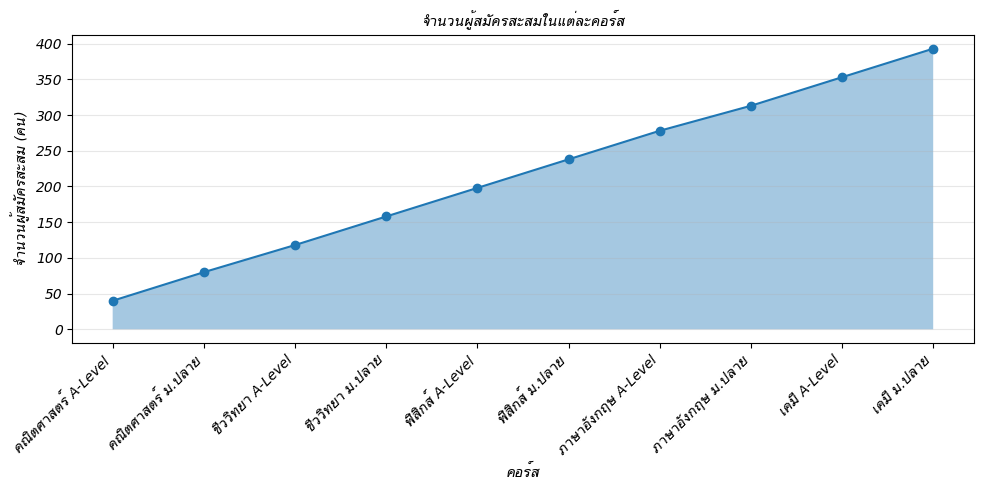

คอร์สที่มีผู้สมัครมากที่สุด จำนวน 40 คน ได้แก่
- คณิตศาสตร์ ม.ปลาย
- ฟิสิกส์ ม.ปลาย
- เคมี ม.ปลาย
- ชีววิทยา ม.ปลาย
- คณิตศาสตร์ A-Level
- ฟิสิกส์ A-Level
- ภาษาอังกฤษ A-Level
- เคมี A-Level


In [53]:
# กราฟ 1: จำนวนผู้สมัครแต่ละคอร์ส
# Area Chart
area_data = q1_pandas.sort_values("ชื่อคอร์ส").copy()
area_data["จำนวนผู้สมัครสะสม"] = area_data["จำนวนผู้สมัคร"].cumsum()
plt.figure(figsize=(10, 5))
plt.fill_between( range(len(area_data)), area_data["จำนวนผู้สมัครสะสม"], alpha=0.4 )
plt.plot( range(len(area_data)), area_data["จำนวนผู้สมัครสะสม"], marker="o" )
plt.title( "จำนวนผู้สมัครสะสมในแต่ละคอร์ส", fontproperties=thai_font )
plt.xlabel( "คอร์ส", fontproperties=thai_font )
plt.ylabel( "จำนวนผู้สมัครสะสม (คน)", fontproperties=thai_font )
plt.xticks( range(len(area_data)), area_data["ชื่อคอร์ส"], rotation=45, ha="right", fontproperties=thai_font )
plt.yticks(fontproperties=thai_font)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

top_course = q1_pandas.iloc[0]
max_applicants = q1_pandas["จำนวนผู้สมัคร"].max()
top_courses = q1_pandas[ q1_pandas["จำนวนผู้สมัคร"] == max_applicants ]
print("คอร์สที่มีผู้สมัครมากที่สุด จำนวน", max_applicants, "คน ได้แก่")
for _, row in top_courses.iterrows():
    print("-", row["ชื่อคอร์ส"])

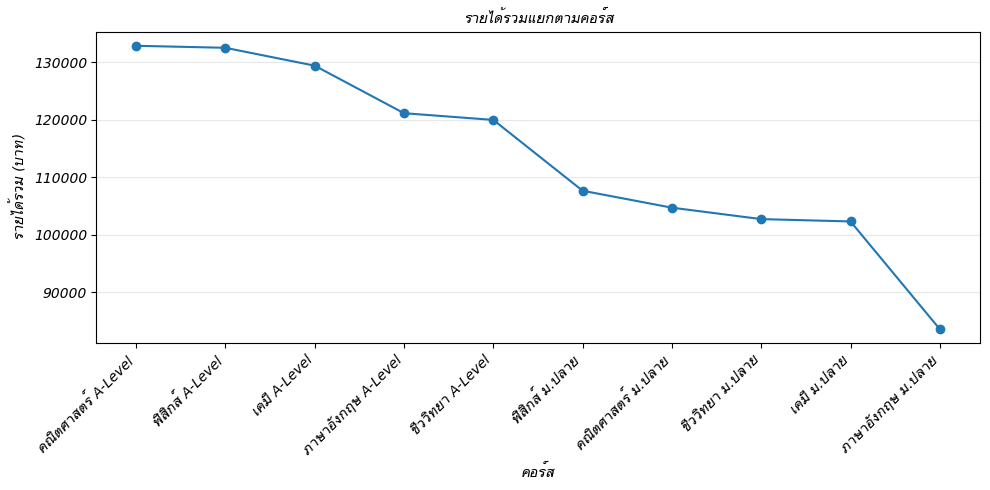

สรุปผล: คอร์สที่สร้างรายได้สูงที่สุดคือ คณิตศาสตร์ A-Level ด้วยรายได้รวม 132,825.00 บาท


In [54]:
# กราฟ 2: รายได้ของแต่ละคอร์ส
# Line Chart
plt.figure(figsize=(10, 5))
plt.plot( q2_pandas["ชื่อคอร์ส"], q2_pandas["รายได้รวม"], marker="o" )
plt.title( "รายได้รวมแยกตามคอร์ส", fontproperties=thai_font )
plt.xlabel( "คอร์ส", fontproperties=thai_font )
plt.ylabel( "รายได้รวม (บาท)", fontproperties=thai_font )
plt.xticks( rotation=45, ha="right", fontproperties=thai_font )
plt.yticks(fontproperties=thai_font)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

top_revenue = q2_pandas.iloc[0]
print( "สรุปผล: คอร์สที่สร้างรายได้สูงที่สุดคือ", top_revenue["ชื่อคอร์ส"], "ด้วยรายได้รวม", f"{top_revenue['รายได้รวม']:,.2f}", "บาท" )

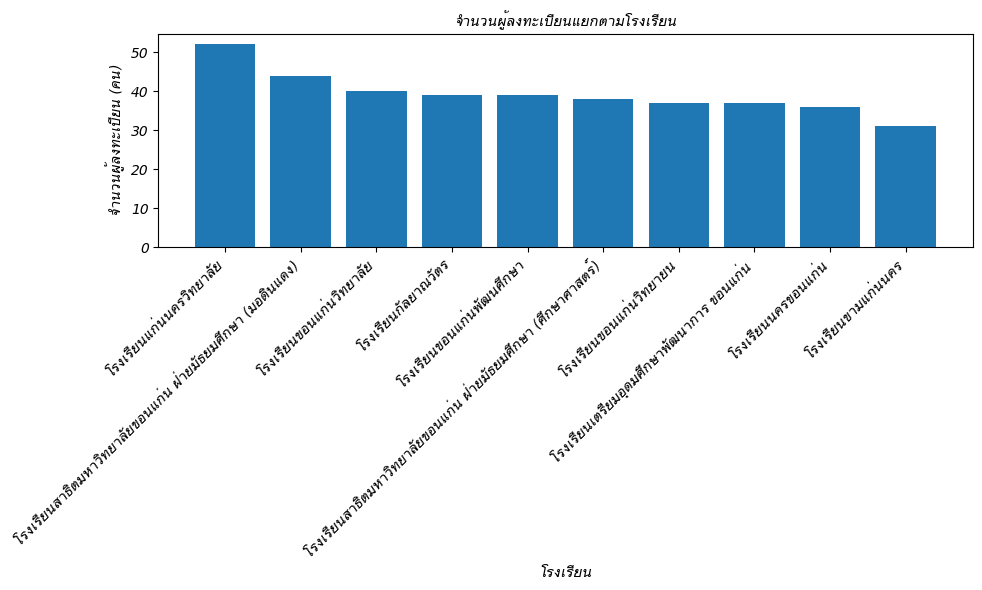

สรุปผล: โรงเรียนที่มีนักเรียนลงทะเบียนมากที่สุดคือ โรงเรียนแก่นนครวิทยาลัย จำนวน 52 คน


In [55]:
# โรงเรียนไหนมีผู้ลงทะเบียนมากที่สุด
top_school = q4_pandas.loc[ q4_pandas["จำนวนผู้ลงทะเบียน"].idxmax() ]

plt.figure(figsize=(10, 6))
plt.bar( q4_pandas["โรงเรียน"], q4_pandas["จำนวนผู้ลงทะเบียน"] )
plt.title( "จำนวนผู้ลงทะเบียนแยกตามโรงเรียน", fontproperties=thai_font )
plt.xlabel( "โรงเรียน", fontproperties=thai_font )
plt.ylabel( "จำนวนผู้ลงทะเบียน (คน)", fontproperties=thai_font )
plt.xticks( rotation=45, ha="right", fontproperties=thai_font )
plt.yticks(fontproperties=thai_font)

plt.tight_layout()
plt.show()


print( "สรุปผล: โรงเรียนที่มีนักเรียนลงทะเบียนมากที่สุดคือ", top_school["โรงเรียน"], "จำนวน", top_school["จำนวนผู้ลงทะเบียน"], "คน" )

จากการวิเคราะห์ข้อมูลพบว่า โรงเรียนแก่นนครวิทยาลัย มีนักเรียนลงทะเบียนมากที่สุด จำนวน 52 คน แสดงให้เห็นว่าเป็นกลุ่มเป้าหมายที่มีความสนใจในการเรียนสูง คอร์สที่มีผู้สมัครมากที่สุดมีทั้งหมด 8 คอร์ส โดยมีผู้สมัครเท่ากันที่ 40 คน ได้แก่ คณิตศาสตร์ ม.ปลาย, ฟิสิกส์ ม.ปลาย, เคมี ม.ปลาย, ชีววิทยา ม.ปลาย, คณิตศาสตร์ A-Level, ฟิสิกส์ A-Level, ภาษาอังกฤษ A-Level และเคมี A-Level นอกจากนี้ คณิตศาสตร์ A-Level เป็นคอร์สที่สร้างรายได้สูงที่สุด โดยมีรายได้รวม 132,825 บาท ดังนั้นโรงเรียนควรพิจารณาเพิ่มรอบเรียนและจัดสรรที่นั่งสำหรับคอร์สที่ได้รับความนิยม รวมถึงใช้ข้อมูลของโรงเรียนและคอร์สที่มีความต้องการสูงในการวางแผนการตลาดต่อไปครับ